In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

df = pd.read_excel("../02_Cleaned_Data/Cleaned_Sales_Data.xlsx")

df.head()

,Order_ID,Order_Date,Customer_Name,Product,Category,Region,Quantity,Unit_Price,Discount,Sales
0,1001,2026-01-05,Aarav Sharma,Laptop,Electronics,North,2,65000,0.05,123500
1,1002,2026-01-08,Priya Mehta,Office Chair,Furniture,West,4,12000,0.10,43200
2,1003,2026-01-12,Rohan Patil,Smartphone,Electronics,South,3,30000,0.05,85500
3,1004,2026-01-18,Sneha Joshi,Desk,Furniture,East,2,18000,0.00,36000
4,1005,2026-01-24,Vikram Shah,Tablet,Electronics,North,5,22000,0.08,101200


In [4]:
df.shape

(40, 10)

In [5]:
df.shape

(40, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       40 non-null     int64         
 1   Order_Date     40 non-null     datetime64[ns]
 2   Customer_Name  40 non-null     object        
 3   Product        40 non-null     object        
 4   Category       40 non-null     object        
 5   Region         40 non-null     object        
 6   Quantity       40 non-null     int64         
 7   Unit_Price     40 non-null     int64         
 8   Discount       40 non-null     float64       
 9   Sales          40 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 3.3+ KB


In [7]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_Name    0
Product          0
Category         0
Region           0
Quantity         0
Unit_Price       0
Discount         0
Sales            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
total_sales = df["Sales"].sum()
total_sales

np.int64(3654410)

In [10]:
total_orders = df["Order_ID"].nunique()
total_orders

40

In [11]:
total_customers = df["Customer_Name"].nunique()
total_customers

40

In [12]:
total_quantity = df["Quantity"].sum()
total_quantity

np.int64(152)

In [13]:
aov = total_sales / total_orders
aov

np.float64(91360.25)

In [14]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Electronics    2794160
Furniture       860250
Name: Sales, dtype: int64

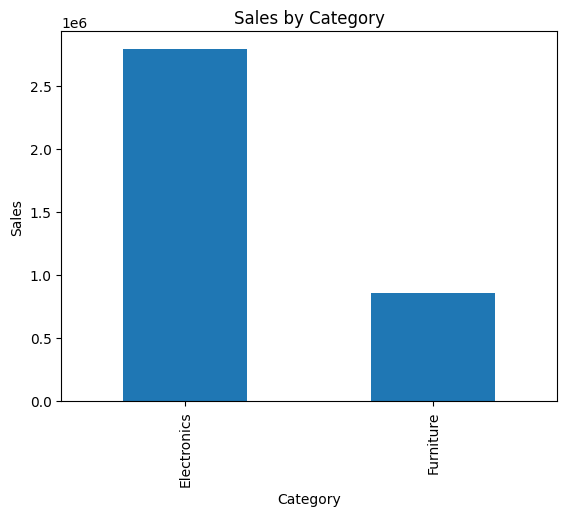

In [15]:
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [16]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

Region
North    1003160
South     917150
West      876400
East      857700
Name: Sales, dtype: int64

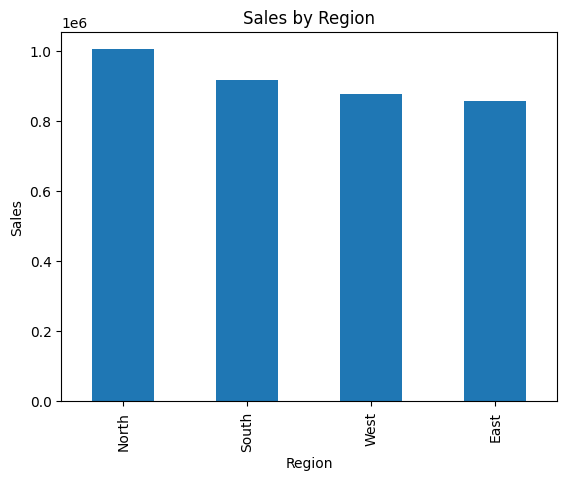

In [17]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

In [18]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
product_sales.head(5)

Product
Laptop          1157000
Smartphone       864300
Tablet           772860
Office Chair     356400
Desk             320400
Name: Sales, dtype: int64

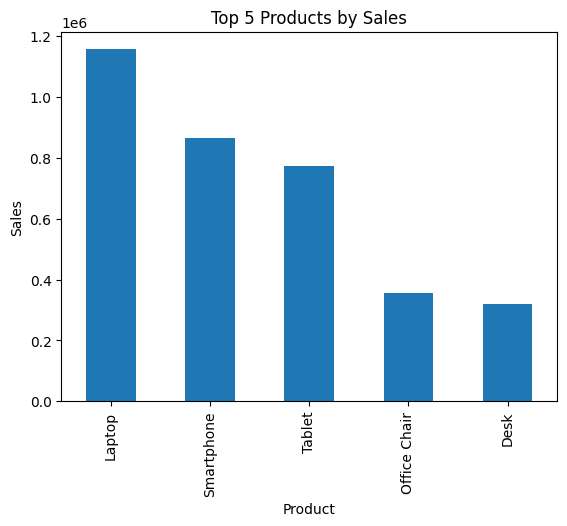

In [19]:
product_sales.head(5).plot(kind="bar")
plt.title("Top 5 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

In [20]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [21]:
monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales

Order_Date
2026-01    389400
2026-02    473750
2026-03    605600
2026-04    310000
2026-05    492710
2026-06    436400
2026-07    515150
2026-08    431400
Freq: M, Name: Sales, dtype: int64

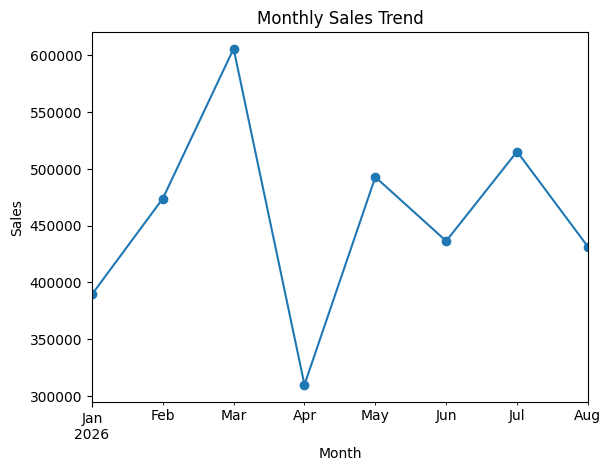

In [22]:
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [23]:
print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Quantity:", total_quantity)
print("Average Order Value:", aov)

Total Sales: 3654410
Total Orders: 40
Total Customers: 40
Total Quantity: 152
Average Order Value: 91360.25
